In [23]:
import json
import sys
from pathlib import Path
import plotly.graph_objects as go
import ipywidgets as widgets
from IPython.display import display
import trimesh
import numpy as np
import pandas as pd
import torch
import trimesh
from sklearn.decomposition import PCA
import umap
import matplotlib.pyplot as plt
# make scripts importable
repo_root = Path("..").resolve()
if str(repo_root) not in sys.path:
    sys.path.append(str(repo_root))

from scripts.pointcloud_ae import PointCloudAutoencoder, find_ply_files, sample_points, normalize_points


In [29]:
CONFIG_PATH = repo_root / "configs" / "pointcloud_ae_maridata.json"
CHECKPOINT_PATH = repo_root / "models" / "pointcloud_ae" / "dgcnn_pointcloud_ae_maridata_best.pth"
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

with open(CONFIG_PATH, "r", encoding="utf-8") as f:
    config = json.load(f)

print("device:", DEVICE)
print("checkpoint:", CHECKPOINT_PATH)


device: cuda
checkpoint: D:\Ziwei\Github\MorphoNuc3D\models\pointcloud_ae\dgcnn_pointcloud_ae_maridata_best.pth


In [30]:
# build model
model = PointCloudAutoencoder(
    n_points=int(config["n_points"]),
    k=int(config["k"]),
    emb_dims=int(config["emb_dims"]),
    latent_dim=int(config["latent_dim"]),
    dropout=float(config.get("dropout", 0.0)),
).to(DEVICE)

ckpt = torch.load(CHECKPOINT_PATH, map_location=DEVICE)
model.load_state_dict(ckpt["model_state_dict"])
model.eval()

print("loaded epoch:", ckpt.get("epoch"))


loaded epoch: 94


In [31]:
data_roots = [repo_root / p for p in config["data_roots"]]
ply_paths = find_ply_files(data_roots, config.get("glob_pattern", "*.ply"))
print("pointclouds objects:", len(ply_paths))


pointclouds objects: 199


In [32]:
def load_one_ply_latent(ply_path, model, n_points, device="cpu"):
    cloud = trimesh.load(ply_path, process=False)
    points = np.asarray(cloud.vertices, dtype=np.float32)
    points = sample_points(points, n_points)
    points = normalize_points(points)

    x = torch.from_numpy(points).unsqueeze(0).to(device=device, dtype=torch.float32)
    with torch.no_grad():
        _, latent = model(x)
    return points, latent.squeeze(0).cpu().numpy()


In [33]:
rows = []
latents = []

for ply_path in ply_paths:
    points, latent = load_one_ply_latent(
        ply_path=ply_path,
        model=model,
        n_points=int(config["n_points"]),
        device=DEVICE,
    )
    latents.append(latent)
    rows.append({
        "ply_path": str(ply_path),
        "name": ply_path.name,
        "parent": ply_path.parent.name,
    })

latent_array = np.stack(latents, axis=0)
meta = pd.DataFrame(rows)

print("latent shape:", latent_array.shape)
meta.head()


latent shape: (199, 128)


,ply_path,name,parent
0,D:\Ziwei\Github\MorphoNuc3D\DATA\Maridata\ST27...,129.ply,selected_basal_
1,D:\Ziwei\Github\MorphoNuc3D\DATA\Maridata\ST27...,142.ply,selected_basal_
2,D:\Ziwei\Github\MorphoNuc3D\DATA\Maridata\ST27...,147.ply,selected_basal_
3,D:\Ziwei\Github\MorphoNuc3D\DATA\Maridata\ST27...,179.ply,selected_basal_
4,D:\Ziwei\Github\MorphoNuc3D\DATA\Maridata\ST27...,231.ply,selected_basal_


In [34]:
pca = PCA(n_components=2)
latent_2d = pca.fit_transform(latent_array)

meta["pc1"] = latent_2d[:, 0]
meta["pc2"] = latent_2d[:, 1]

c:\Users\ljd567\AppData\Local\miniconda3\envs\torch_env\lib\site-packages\umap\umap_.py:1945: UserWarning:

n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.



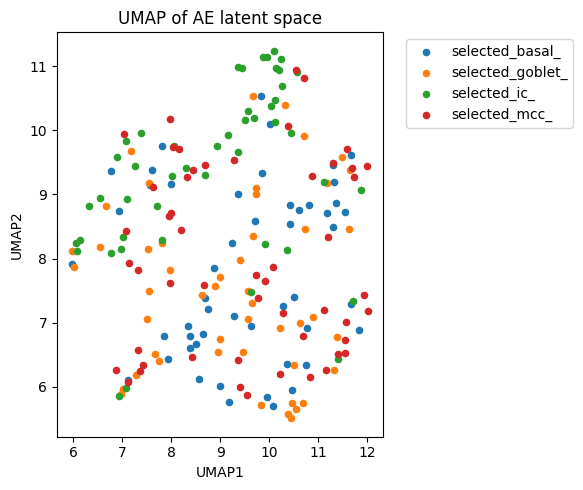

In [45]:
import umap

embed = umap.UMAP(n_neighbors=15, min_dist=0.1, random_state=42).fit_transform(latent_array)
meta["umap1"] = embed[:, 0]
meta["umap2"] = embed[:, 1]

plt.figure(figsize=(6, 5))
for label, df_sub in meta.groupby("parent"):
    plt.scatter(df_sub["umap1"], df_sub["umap2"], s=20, label=label)

plt.xlabel("UMAP1")
plt.ylabel("UMAP2")
plt.title("UMAP of AE latent space")
plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()
plt.show()

In [46]:
def load_plotly_pointcloud(ply_path, point_size=20):
    cloud = trimesh.load(ply_path, process=False)
    pts = np.asarray(cloud.vertices, dtype=np.float32)

    fig = go.FigureWidget(
        data=[
            go.Scatter3d(
                x=pts[:, 2],
                y=pts[:, 1],
                z=pts[:, 0],
                mode="markers",
                marker=dict(
                    size=point_size,
                    opacity=0.8,
                ),
            )
        ]
    )

    fig.update_layout(
        title=Path(ply_path).name,
        width=700,
        height=700,
        scene=dict(
            xaxis_title="X",
            yaxis_title="Y",
            zaxis_title="Z",
            aspectmode="data",
        ),
        margin=dict(l=0, r=0, b=0, t=40),
    )
    return fig



In [47]:
cloud_out = widgets.Output()
info_out = widgets.Output()
selected_index = {"idx": 0}


In [48]:
def load_points_and_reconstruction(ply_path, model, n_points, device="cpu"):
    cloud = trimesh.load(ply_path, process=False)
    points = np.asarray(cloud.vertices, dtype=np.float32)
    points = sample_points(points, n_points)
    points = normalize_points(points)

    x = torch.from_numpy(points).unsqueeze(0).to(device=device, dtype=torch.float32)
    with torch.no_grad():
        recon, latent = model(x)

    recon = recon.squeeze(0).cpu().numpy()
    latent = latent.squeeze(0).cpu().numpy()
    return points, recon, latent

In [49]:
def update_cloud(idx):
    row = meta.iloc[idx]
    ply_path = Path(row["ply_path"])

    points, recon, latent = load_points_and_reconstruction(
        ply_path=ply_path,
        model=model,
        n_points=int(config["n_points"]),
        device=DEVICE,
    )

    with info_out:
        info_out.clear_output(wait=True)
        print(f"idx: {idx}")
        print(f"name: {row['name']}")
        if "parent" in row:
            print(f"parent: {row['parent']}")
        print(f"path: {ply_path}")
        print(f"latent norm: {np.linalg.norm(latent):.3f}")

    fig = make_subplots(
        rows=1,
        cols=2,
        specs=[[{"type": "scene"}, {"type": "scene"}]],
        subplot_titles=("Original", "Reconstruction"),
    )

    fig.add_trace(
        go.Scatter3d(
            x=points[:, 2],
            y=points[:, 1],
            z=points[:, 0],
            mode="markers",
            marker=dict(size=2, color="royalblue", opacity=0.8),
        ),
        row=1,
        col=1,
    )

    fig.add_trace(
        go.Scatter3d(
            x=recon[:, 2],
            y=recon[:, 1],
            z=recon[:, 0],
            mode="markers",
            marker=dict(size=2, color="crimson", opacity=0.8),
        ),
        row=1,
        col=2,
    )

    fig.update_layout(height=500, width=900, showlegend=False)
    fig.update_scenes(aspectmode="data")

    with cloud_out:
        cloud_out.clear_output(wait=True)
        display(fig)

In [ ]:
meta["parent_code"] = meta["parent"].astype("category").cat.codes

latent_fig = go.FigureWidget(
    data=[
        go.Scattergl(
            x=meta["umap1"],
            y=meta["umap2"],
            mode="markers",
            marker=dict(
                size=8,
                opacity=0.8,
                color=meta["parent_code"],
                colorscale="Turbo",
                showscale=True,
                colorbar=dict(title="parent"),
            ),
            text=meta["name"],
            customdata=np.arange(len(meta)),
            hovertemplate="idx=%{customdata}<br>%{text}<br>parent=%{marker.color}<extra></extra>",
        )
    ]
)

latent_fig.update_layout(
    title="UMAP of AE latent space",
    width=700,
    height=500,
    xaxis_title="UMAP1",
    yaxis_title="UMAP2",
)


FigureWidget({
    'data': [{'customdata': array([  0,   1,   2,   3,   4,   5,   6,   7,   8,   9,  10,  11,  12,  13,
                                    14,  15,  16,  17,  18,  19,  20,  21,  22,  23,  24,  25,  26,  27,
                                    28,  29,  30,  31,  32,  33,  34,  35,  36,  37,  38,  39,  40,  41,
                                    42,  43,  44,  45,  46,  47,  48,  49,  50,  51,  52,  53,  54,  55,
                                    56,  57,  58,  59,  60,  61,  62,  63,  64,  65,  66,  67,  68,  69,
                                    70,  71,  72,  73,  74,  75,  76,  77,  78,  79,  80,  81,  82,  83,
                                    84,  85,  86,  87,  88,  89,  90,  91,  92,  93,  94,  95,  96,  97,
                                    98,  99, 100, 101, 102, 103, 104, 105, 106, 107, 108, 109, 110, 111,
                                   112, 113, 114, 115, 116, 117, 118, 119, 120, 121, 122, 123, 124, 125,
                                   126, 

In [52]:
from plotly.subplots import make_subplots
info_out.clear_output()
cloud_out.clear_output()

def handle_click(trace, points, selector):
    if not points.point_inds:
        return
    idx = int(trace.customdata[points.point_inds[0]])
    update_cloud(idx)

latent_fig.data[0].on_click(handle_click)

update_cloud(0)
display(widgets.VBox([latent_fig, info_out, cloud_out]))


    'data': [{'customdata': array([  0,   1,   2,   3,   4,   5,   6,   7,   8, …